# **EDA DATASET PARA CLASIFICACIÓN BINARIA (utilizando spaCy)**

Análisis Exploratorio del conjunto de datos **Data_Bin_Classiffier.csv** que es el resultado de unir los conjuntos de datos de la carpeta "Data" y contiene las columnas:

* **ID**: Identificador único de cada registro (`string` de la forma `BIN_1`, `BIN_2`...)
* **Title**: Título de la noticia (`string`)
* **Content**: Contenido de la noticia (`string`)
* **State**: **TARGET** que indica el estado la noticia (`boolean` discreto): `False / True`
* **Dataset**: Dataset de donde proviene esa noticia (`string`)

En este notebook realizaremos un EDA avanzado utilizando **spaCy** para desentrañar patrones lingüísticos complejos en el dataset de noticias falsas.

**INSTALACIÓN DE DEPENDENCIAS Y MODELOS**

In [1]:
#%pip install spacy seaborn matplotlib wordcloud tqdm
#!python -m spacy download es_core_news_lg

## **0. CONFIGURACIÓN DE LA PIPELINE DE PLN**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import Counter
from wordcloud import WordCloud
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')

# 1. Configuración Estética
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'serif'
sns.set_palette("viridis")
sns.set_style("whitegrid")

# 2. Carga del modelo
print("Cargando modelo es_core_news_lg... (esto puede tardar unos segundos)")
nlp = spacy.load("es_core_news_lg")

# 3. Carga y limpieza de datos
df_bin = pd.read_csv('Data_Bin_Classifier.csv')
df_bin['Title'] = df_bin['Title'].fillna('')
df_bin['Content'] = df_bin['Content'].fillna('')

print(f"Dataset cargado correctamente. Dimensiones: {df_bin.shape}")
df_bin.head()

c:\Users\User\Desktop\Cursos Formación\Apuntes M\2do Cuatri\TFM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando modelo es_core_news_lg... (esto puede tardar unos segundos)
Dataset cargado correctamente. Dimensiones: (62894, 5)


,ID,Title,Content,State,Dataset
0,BIN_0,,El suceso ha tenido lugar en Brasil. Un adole...,False,Fake News Detector Spanish News Edition
1,BIN_1,"""La quimioterapia mata a la gente y no al cánc...",Estamos en la semana decisiva. Los expertos a...,False,Fake News Detector Spanish News Edition
2,BIN_2,Los Cubos De Caldo Para Cocinar Son Veneno Par...,Estudios científicos hay muchos. Unos nos int...,False,Fake News Detector Spanish News Edition
3,BIN_3,MEGATERREMOTO EN LOS PRÓXIMOS DÍAS ALINEACIÓN ...,Ha sucedido en la ciudad de San José de Río P...,False,Fake News Detector Spanish News Edition
4,BIN_4,¡Qué injusticia! El perro que defendió su casa...,La fiesta en Sevilla por el vuelco electoral ...,False,Fake News Detector Spanish News Edition


**Datos nulos, duplicados o faltantes**

In [3]:
# Verificamos valores nulos (faltantes) por columna
print("--- VALORES NULOS POR COLUMNA ---")
display(df_bin.isnull().sum())

# Verificamos registros duplicados exactos en el dataset
duplicados = df_bin.duplicated().sum()
print(f"\n--- REGISTROS DUPLICADOS ---")
print(f"Total de filas duplicadas: {duplicados}")

if duplicados > 0:
    porcentaje_dup = (duplicados / len(df_bin)) * 100
    print(f"Porcentaje de duplicados sobre el total: {porcentaje_dup:.2f}%")
    
    # Descomenta la siguiente línea si deseas eliminar los duplicados automáticamente:
    # df_bin = df_bin.drop_duplicates().reset_index(drop=True)
    # print("Duplicados eliminados.")

--- VALORES NULOS POR COLUMNA ---


ID         0
Title      0
Content    0
State      0
Dataset    0
dtype: int64


--- REGISTROS DUPLICADOS ---
Total de filas duplicadas: 0


## **1. Balanceo de clases**

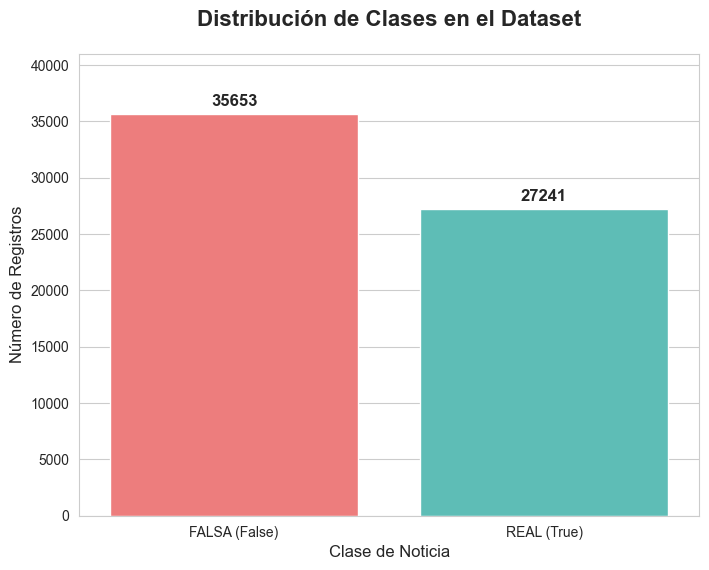

Porcentaje de balanceo:
- Noticias Falsas: 56.69%
- Noticias Reales: 43.31%


In [4]:
plt.figure(figsize=(8, 6))

# Creamos el gráfico de frecuencias
ax = sns.countplot(x='State', data=df_bin, palette=['#FF6B6B', '#4ECDC4'])

# Personalización estética
plt.title('Distribución de Clases en el Dataset', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Clase de Noticia', fontsize=12)
plt.ylabel('Número de Registros', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['FALSA (False)', 'REAL (True)'])

# Añadimos los números encima de cada barra para mayor precisión
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=12,
                fontweight='bold')

# Añair un margen superior para que no se corten los números
plt.ylim(0, df_bin['State'].value_counts().max() * 1.15)
plt.show()

# Imprimir el porcentaje de balanceo
counts = df_bin['State'].value_counts(normalize=True) * 100
print(f"Porcentaje de balanceo:")
print(f"- Noticias Falsas: {counts[False]:.2f}%")
print(f"- Noticias Reales: {counts[True]:.2f}%")

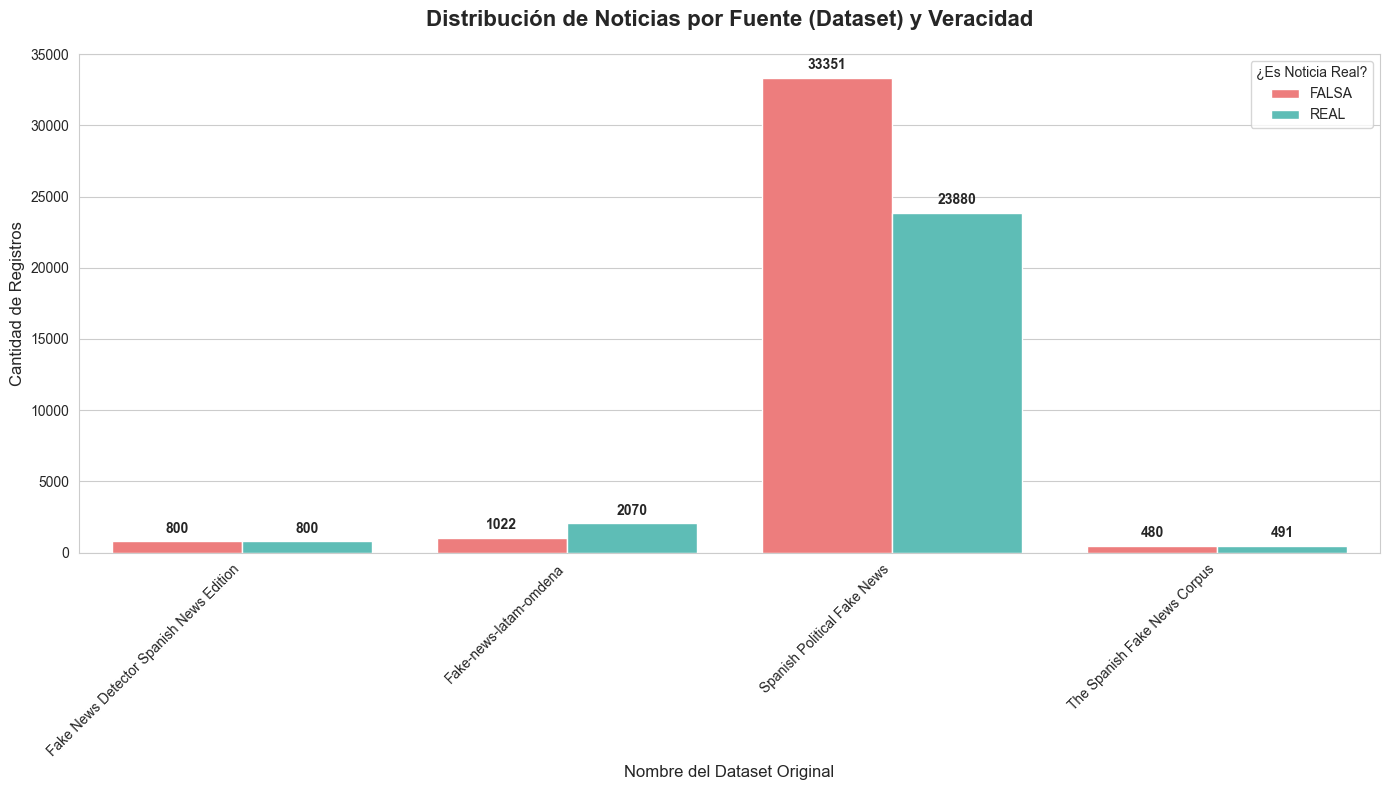


--- RESUMEN NUMÉRICO POR DATASET ---


,Falsas,Reales,Total
Dataset,,,
Fake News Detector Spanish News Edition,800,800,1600
Fake-news-latam-omdena,1022,2070,3092
Spanish Political Fake News,33351,23880,57231
The Spanish Fake News Corpus,480,491,971
Total,35653,27241,62894


In [5]:
plt.figure(figsize=(14, 8))

# Creamos un gráfico de barras agrupado por Dataset y State
ax = sns.countplot(x='Dataset', hue='State', data=df_bin, palette=['#FF6B6B', '#4ECDC4'])

# Configuración de títulos y etiquetas
plt.title('Distribución de Noticias por Fuente (Dataset) y Veracidad', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nombre del Dataset Original', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='¿Es Noticia Real?', labels=['FALSA', 'REAL'])

# Añadimos etiquetas de valor sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Solo ponemos etiqueta si hay datos
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

# Ajustamos el layout para que no se corten las etiquetas del eje X
plt.tight_layout()
plt.show()

# Resumen numérico en tabla para mayor claridad
print("\n--- RESUMEN NUMÉRICO POR DATASET ---")
resumen = pd.crosstab(df_bin['Dataset'], df_bin['State'], margins=True, margins_name="Total")
resumen.columns = ['Falsas', 'Reales', 'Total']
display(resumen)


## **2. PREPROCESAMIENTO (Lematización y Filtrado)**

Vamos a procesar los textos con spaCy para extraer lemas, etiquetas POS y entidades. Con el fin de optimizar, limitaremos el análisis a una muestra si el dataset es excesivamente grande, aunque para este EDA intentaremos procesarlo todo.

In [6]:
def process_nlp_batch(texts):
    """Procesa una lista de textos usando nlp.pipe para máxima eficiencia."""
    results = []
    # Usamos nlp.pipe para procesar en lotes (multi-thread)
    for doc in tqdm(nlp.pipe(texts, batch_size=50), total=len(texts), desc="Procesando PLN"):
        features = [{
            'lemma': token.lemma_.lower(),
            'pos': token.pos_,
            'is_stop': token.is_stop,
            'ent_type': token.ent_type_
        } for token in doc if not token.is_stop and not token.is_punct and not token.is_space]
        results.append(features)
    return results

print("Iniciando procesamiento avanzado con spaCy...")
# Procesamos el contenido y lo guardamos
df_bin['nlp_content'] = process_nlp_batch(df_bin['Content'].tolist())
print("¡Procesamiento completado con éxito!")

Iniciando procesamiento avanzado con spaCy...


Procesando PLN: 100%|██████████| 62894/62894 [03:00<00:00, 348.44it/s]

¡Procesamiento completado con éxito!


## **3. ANÁLISIS DE CATEGORÍAS GRAMATICALES (POS)**

¿Difieren las noticias reales de las falsas en su composición gramatical? Por ejemplo, ¿hay más adjetivos en las noticias falsas?

Calculando distribución de categorías gramaticales...


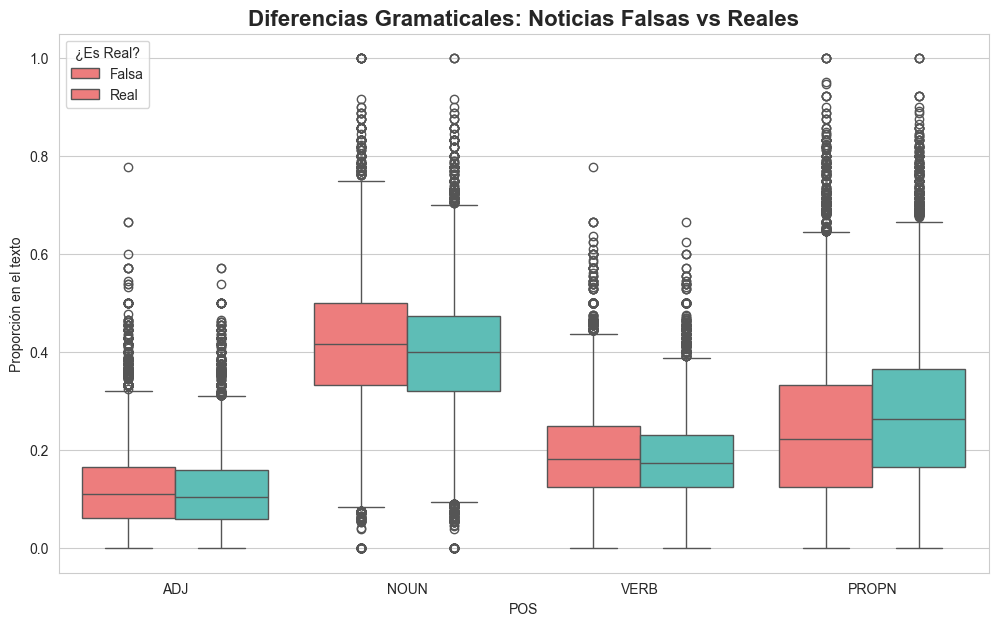

In [7]:
def get_pos_distribution(nlp_list):
    if not nlp_list: return {}
    counts = Counter([item['pos'] for item in nlp_list])
    total = sum(counts.values())
    return {k: v/total for k, v in counts.items()} if total > 0 else {}

print("Calculando distribución de categorías gramaticales...")
pos_dist = df_bin['nlp_content'].apply(get_pos_distribution)
df_pos = pd.DataFrame(list(pos_dist)).fillna(0)
df_pos['State'] = df_bin['State']

# Visualización comparativa
pos_to_plot = ['ADJ', 'NOUN', 'VERB', 'PROPN']
df_pos_melted = df_pos.melt(id_vars='State', value_vars=pos_to_plot, var_name='POS', value_name='Proportion')

plt.figure(figsize=(12, 7))
# El color representará si la noticia es Falsa (False) o Real (True)
sns.boxplot(x='POS', y='Proportion', hue='State', data=df_pos_melted, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Diferencias Gramaticales: Noticias Falsas vs Reales', fontsize=16, fontweight='bold')
plt.ylabel('Proporción en el texto')
plt.legend(title='¿Es Real?', labels=['Falsa', 'Real'])
plt.show()


## **4. ANÁLISIS DE ENTIDADES NOMBRADAS (NER)**

Identifiquemos qué tipo de entidades se mencionan más en cada clase.

Extrayendo entidades...


100%|██████████| 62894/62894 [04:48<00:00, 217.66it/s]


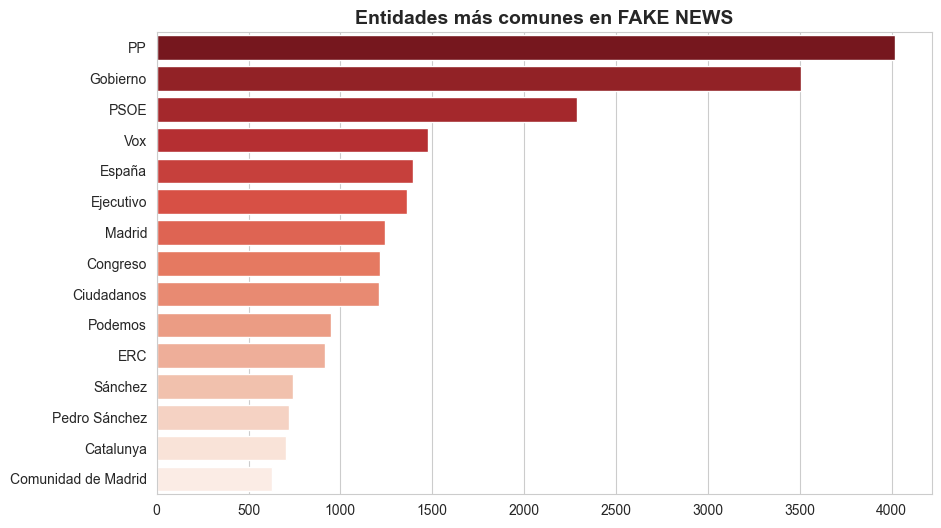

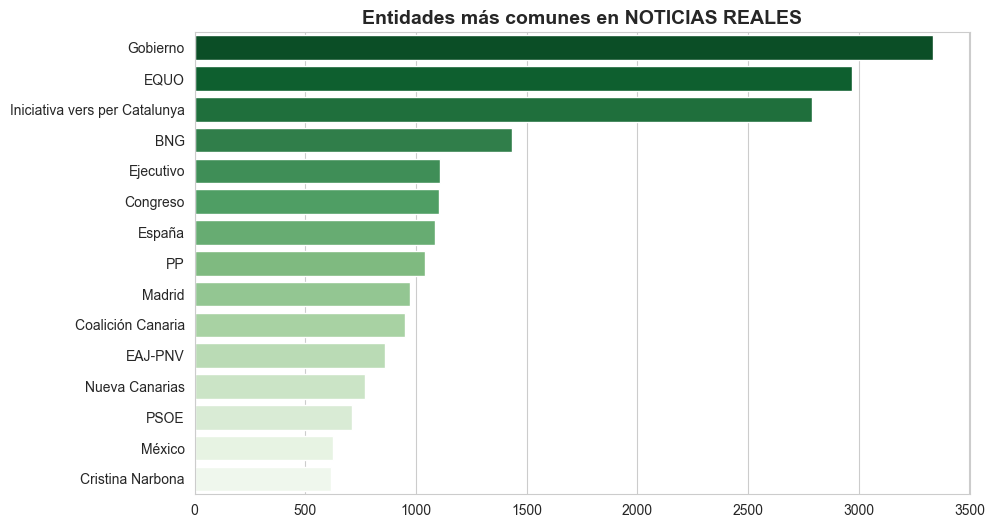

In [13]:
tqdm.pandas()

def get_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

print("Extrayendo entidades...")
df_bin['entities'] = df_bin['Content'].progress_apply(get_entities)

def plot_most_common_entities(df, state, title, color):
    all_ents = [ent[0] for sublist in df[df['State'] == state]['entities'] for ent in sublist]
    common = Counter(all_ents).most_common(15)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=[x[1] for x in common], y=[x[0] for x in common], palette=color)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.show()

plot_most_common_entities(df_bin, False, 'Entidades más comunes en FAKE NEWS', 'Reds_r')
plot_most_common_entities(df_bin, True, 'Entidades más comunes en NOTICIAS REALES', 'Greens_r')

## **5. WORDCLOUDS BASADAS EN LEMAS**

Al usar lemas, agrupamos todas las variantes de una palabra (ej. plurales, conjugaciones) obteniendo una visión más pura del contenido semántico.

Generando WordClouds...


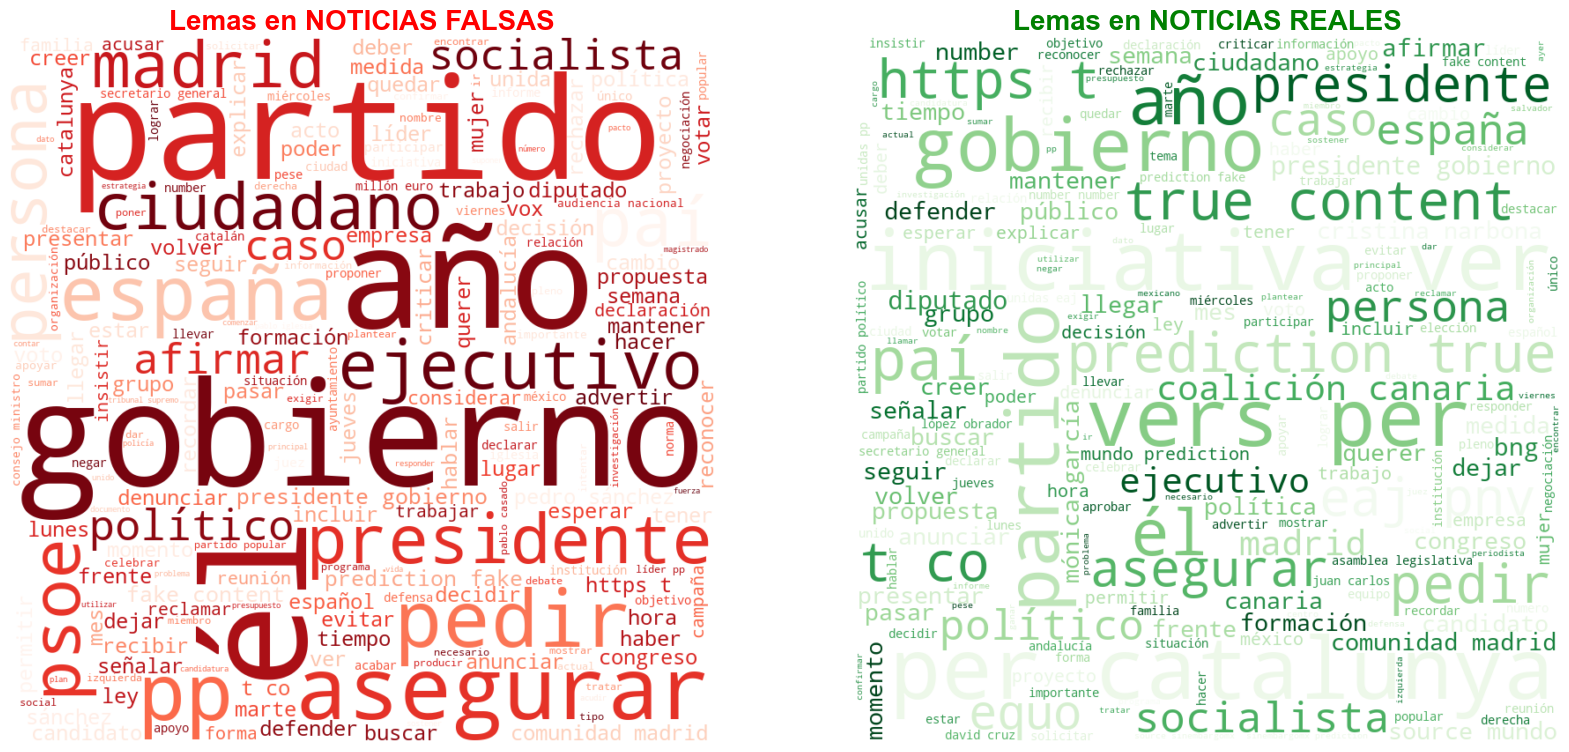

In [10]:
def get_lemmas_string(nlp_rows):
    return " ".join([item['lemma'] for row in nlp_rows for item in row])

print("Generando WordClouds...")
fake_lemmas = get_lemmas_string(df_bin[df_bin['State'] == False]['nlp_content'])
real_lemmas = get_lemmas_string(df_bin[df_bin['State'] == True]['nlp_content'])

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

wc_fake = WordCloud(width=800, height=800, background_color='white', colormap='Reds').generate(fake_lemmas)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Lemas en NOTICIAS FALSAS', fontsize=20, fontweight='bold', color='red')
axes[0].axis('off')

wc_real = WordCloud(width=800, height=800, background_color='white', colormap='Greens').generate(real_lemmas)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Lemas en NOTICIAS REALES', fontsize=20, fontweight='bold', color='green')
axes[1].axis('off')

plt.show()

## **6. Estadísticas por clase**

In [11]:
def extract_linguistic_stats(texts):
    """Extrae contadores estadísticos de forma eficiente."""
    stats = []
    # Usamos nlp.pipe para procesar todo el bloque de una vez
    for doc in tqdm(nlp.pipe(texts, batch_size=50), total=len(texts), desc="Calculando Estadísticas"):
        stats.append({
            'Número de Palabras': len([t for t in doc if not t.is_punct and not t.is_space]),
            'Número de Frases': len(list(doc.sents)),
            'Número de NER': len(doc.ents),
            'Número de signos de puntuación': len([t for t in doc if t.is_punct]),
            'Número de Verbos': len([t for t in doc if t.pos_ == 'VERB'])
        })
    return pd.DataFrame(stats)

print("Calculando promedios lingüísticos por clase...")
# 1. Extraemos las estadísticas
df_stats = extract_linguistic_stats(df_bin['Content'].tolist())
df_stats['State'] = df_bin['State']

# 2. Calculamos las medias agrupadas por 'State' (Veracidad)
# State=False suelen ser Fake, State=True son Reales
summary_stats = df_stats.groupby('State').mean().reset_index()

# 3. Presentación limpia de resultados
# Renombramos el estado para que sea más legible
summary_stats['Clase'] = summary_stats['State'].map({False: 'NOTICIA FALSA', True: 'NOTICIA REAL'})
summary_stats = summary_stats.drop(columns=['State']).set_index('Clase')

Calculando promedios lingüísticos por clase...


Calculando Estadísticas: 100%|██████████| 62894/62894 [02:58<00:00, 352.13it/s]



--- PROMEDIO DE MÉTRICAS POR DOCUMENTO ---


,Número de Palabras,Número de Frases,Número de NER,Número de signos de puntuación,Número de Verbos
Clase,,,,,
NOTICIA FALSA,43.59,1.67,3.40,4.04,4.39
NOTICIA REAL,56.68,2.14,4.63,6.10,5.52


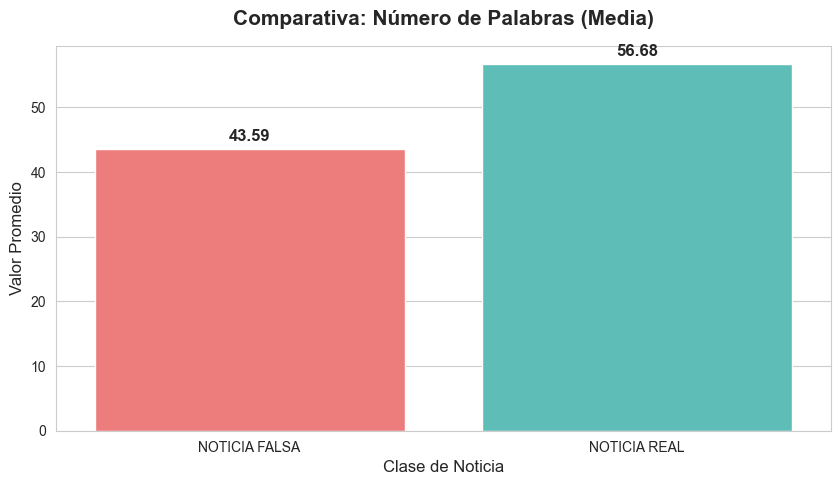

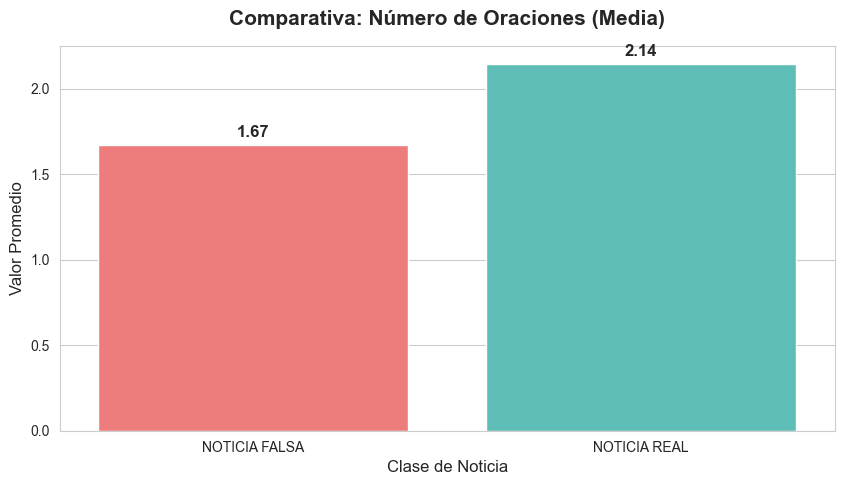

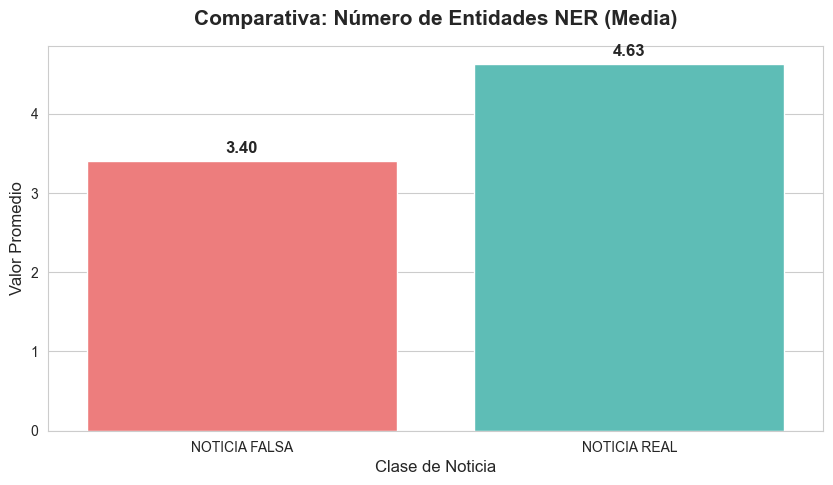

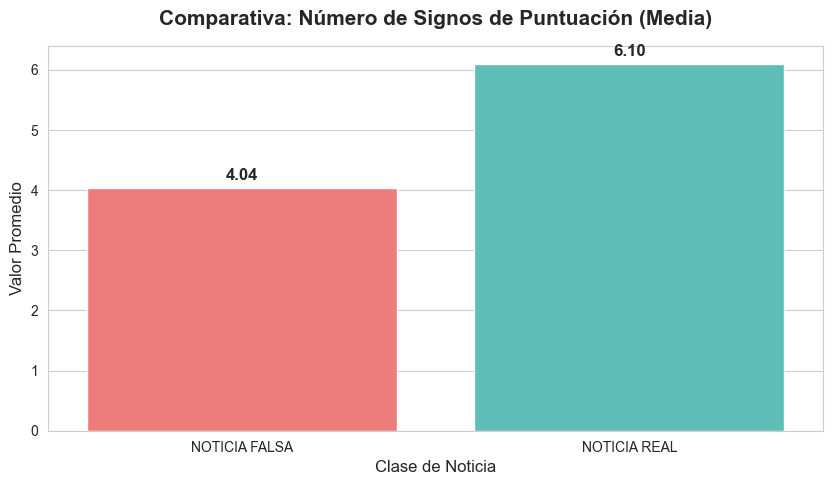

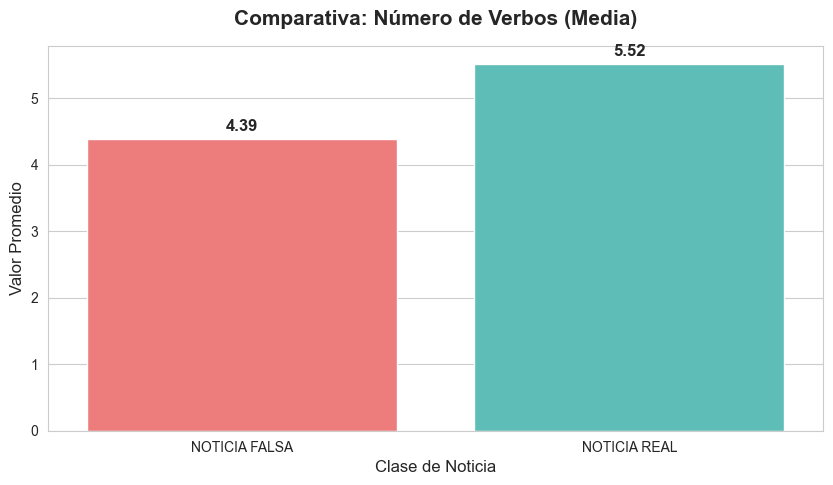

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- PROMEDIO DE MÉTRICAS POR DOCUMENTO ---")
display(summary_stats.style.format("{:.2f}"))

# Graficamos cada métrica de forma independiente
metrics = ['Número de Palabras', 'Número de Frases', 'Número de NER', 'Número de signos de puntuación', 'Número de Verbos']
titulos = [
    'Número de Palabras (Media)', 
    'Número de Oraciones (Media)', 
    'Número de Entidades NER (Media)', 
    'Número de Signos de Puntuación (Media)', 
    'Número de Verbos (Media)'
]
colores = ['#FF6B6B', '#4ECDC4'] # Rojo para Falsas, Verde para Reales

for i, col in enumerate(metrics):
    plt.figure(figsize=(10, 5))
    
    # Creamos el gráfico individual
    ax = sns.barplot(x=summary_stats.index, y=col, data=summary_stats, palette=colores)
    
    # Personalización
    plt.title(f'Comparativa: {titulos[i]}', fontsize=15, fontweight='bold', pad=15)
    plt.ylabel('Valor Promedio', fontsize=12)
    plt.xlabel('Clase de Noticia', fontsize=12)
    
    # Añadir el valor exacto sobre la barra
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')
    
    plt.show()
    print("\n" + "="*60 + "\n") # Separador visual entre gráficos

## **CONCLUSIÓN DEL EDA**

* Dataset muy balanceado, con muchos registros y con clases separadas, se espera alcanzar modelos con rendimiento alto
* Se podrían incluir features como las características que se han comentado al final que podrían ser interesantes a la hora de realizar las predicciones.
* Tener cuidado al realizar el Split ya que se debe escoger una muestra representativa de cada dataset.